In [1]:
!pip install opencv-python
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset, WeightedRandomSampler
from torchvision import transforms, datasets, models
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires

In [2]:
class CLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img = np.array(img)
        if len(img.shape) == 3:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            lab[:, :, 0] = self.clahe.apply(lab[:, :, 0])
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

class GaussianNoise(object):
    def __init__(self, std=0.02):
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std

print("Custom transforms defined ✓")

Custom transforms defined ✓


In [3]:
TRAIN_DIR = '/home/sagemaker-user/dataset_classification/Training'
TEST_DIR  = '/home/sagemaker-user/dataset_classification/Testing'
IMG_SIZE  = 224

train_transforms = transforms.Compose([
    CLAHE(clip_limit=2.0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    GaussianNoise(std=0.02)
])

test_transforms = transforms.Compose([
    CLAHE(clip_limit=2.0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms defined ✓")

Transforms defined ✓


In [4]:
# Load split indices generated from custom_cnn.ipynb
with open('/home/sagemaker-user/NeuroVision/split_indices.json', 'r') as f:
    split_data = json.load(f)

train_idx = split_data['train']
val_idx   = split_data['val']
test_idx  = split_data['test']

# Load using same method as custom_cnn to guarantee index alignment
base_train = datasets.ImageFolder(TRAIN_DIR)
base_test  = datasets.ImageFolder(TEST_DIR)
targets    = base_train.targets + base_test.targets
class_names = base_train.classes
print(f"Classes: {class_names}")
print(f"Total samples: {len(targets)}")

# Build subsets with transforms
train_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=train_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=train_transforms)
]), train_idx)

val_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=test_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=test_transforms)
]), val_idx)

test_dataset = Subset(ConcatDataset([
    datasets.ImageFolder(TRAIN_DIR, transform=test_transforms),
    datasets.ImageFolder(TEST_DIR,  transform=test_transforms)
]), test_idx)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Weighted sampler
train_targets  = [targets[i] for i in train_idx]
class_counts   = Counter(train_targets)
weights        = [1.0 / class_counts[t] for t in train_targets]
sampler        = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# DataLoaders
BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready ✓")

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Total samples: 3264

Train: 2284 | Val: 490 | Test: 490
DataLoaders ready ✓


In [5]:
# Class weights for imbalanced loss
class_counts_all = Counter(targets)
total            = len(targets)
class_weights    = torch.tensor(
    [total / class_counts_all[i] for i in range(4)],
    dtype=torch.float
).to(device)
print(f"Class weights: { {class_names[i]: round(class_weights[i].item(), 3) for i in range(4)} }")

# ResNet50 with pretrained ImageNet weights
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Unfreeze all layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Replace classifier head
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4)
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Class weights: {'glioma_tumor': 3.525, 'meningioma_tumor': 3.483, 'no_tumor': 6.528, 'pituitary_tumor': 3.623}


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/sagemaker-user/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 248MB/s]


Trainable parameters: 24,559,172


In [6]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("Loss, optimizer, scheduler ready ✓")

Loss, optimizer, scheduler ready ✓


In [7]:
NUM_EPOCHS      = 50
EARLY_STOP      = 10
best_val_loss   = float('inf')
no_improve      = 0
best_model_path = '/home/sagemaker-user/NeuroVision/resnet50_best.pth'

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    running_loss, correct, total_seen = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total_seen   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total_seen

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            val_loss      += loss.item()
            _, predicted   = outputs.max(1)
            val_correct   += predicted.eq(labels).sum().item()
            val_total     += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = 100. * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), best_model_path)
        saved = "← saved"
    else:
        no_improve += 1
        saved = ""

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}% | "
          f"No improve: {no_improve}/{EARLY_STOP} {saved}")

    if no_improve >= EARLY_STOP:
        print(f"\nEarly stopping triggered at epoch {epoch+1} ✓")
        break

print("\nTraining complete ✓")
print(f"Best val loss: {best_val_loss:.4f}")

Epoch 1 [Train]: 100%|██████████| 72/72 [00:51<00:00,  1.40it/s]


Epoch [01/50] Train Loss: 0.6089 Acc: 76.9% | Val Loss: 0.6646 Acc: 81.4% | No improve: 0/10 ← saved


Epoch 2 [Train]: 100%|██████████| 72/72 [00:49<00:00,  1.46it/s]


Epoch [02/50] Train Loss: 0.3470 Acc: 86.4% | Val Loss: 0.4918 Acc: 80.2% | No improve: 0/10 ← saved


Epoch 3 [Train]: 100%|██████████| 72/72 [00:48<00:00,  1.48it/s]


...

Epoch [24/50] Train Loss: 0.0290 Acc: 98.7% | Val Loss: 0.2603 Acc: 95.7% | No improve: 8/10 


Epoch 25 [Train]: 100%|██████████| 72/72 [00:47<00:00,  1.51it/s]


Epoch [25/50] Train Loss: 0.0223 Acc: 99.2% | Val Loss: 0.2494 Acc: 95.9% | No improve: 9/10 


Epoch 26 [Train]: 100%|██████████| 72/72 [00:48<00:00,  1.49it/s]


Epoch [26/50] Train Loss: 0.0244 Acc: 99.0% | Val Loss: 0.2909 Acc: 94.9% | No improve: 10/10 

Early stopping triggered at epoch 26 ✓

Training complete ✓
Best val loss: 0.1691


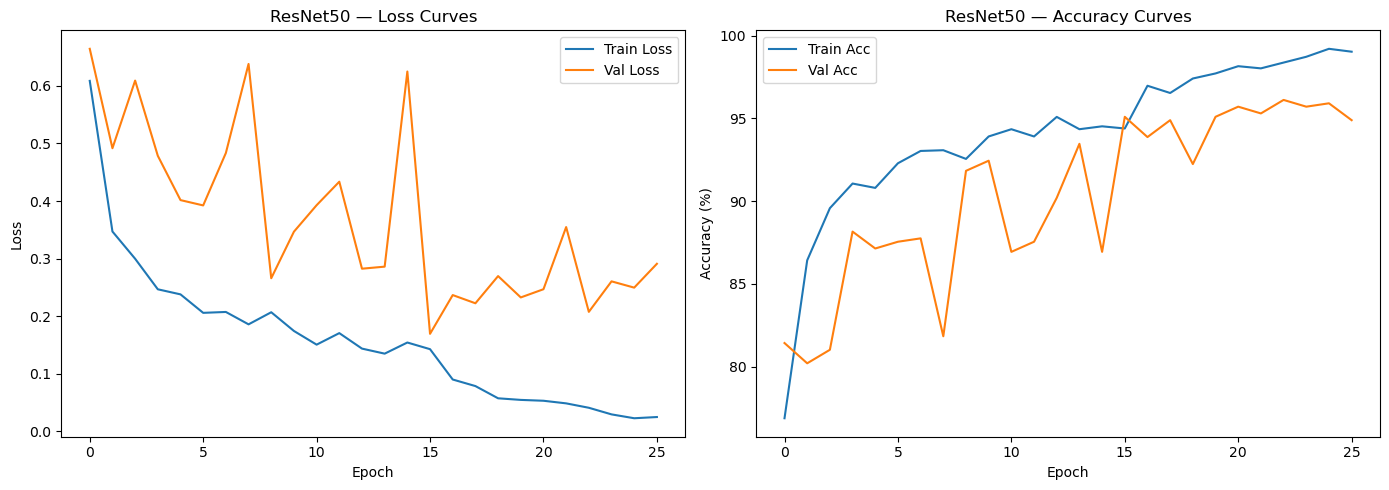

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('ResNet50 — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('ResNet50 — Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/resnet50_training_curves.png', dpi=150)
plt.show()

In [9]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

weighted_f1  = f1_score(all_labels, all_preds, average='weighted')
test_acc     = 100. * np.sum(all_preds == all_labels) / len(all_labels)

print("=" * 50)
print("RESNET50 — FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Test Accuracy:    {test_acc:.2f}%")
print(f"Weighted F1:      {weighted_f1:.4f}")
print("=" * 50)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.92      0.91       139
meningioma_tumor       0.90      0.87      0.89       141
        no_tumor       0.95      0.97      0.96        75
 pituitary_tumor       0.96      0.96      0.96       135

        accuracy                           0.93       490
       macro avg       0.93      0.93      0.93       490
    weighted avg       0.93      0.93      0.93       490

RESNET50 — FINAL RESULTS SUMMARY
Test Accuracy:    92.65%
Weighted F1:      0.9263


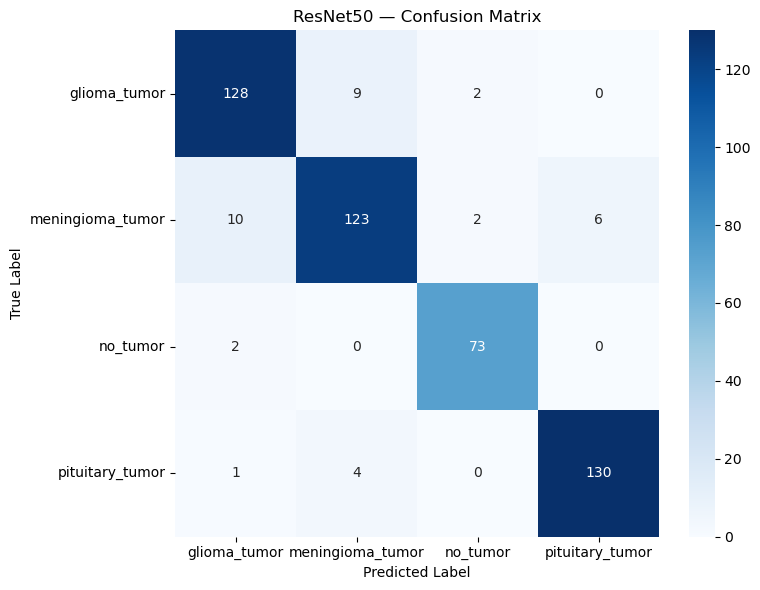

In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('ResNet50 — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/resnet50_confusion_matrix.png', dpi=150)
plt.show()

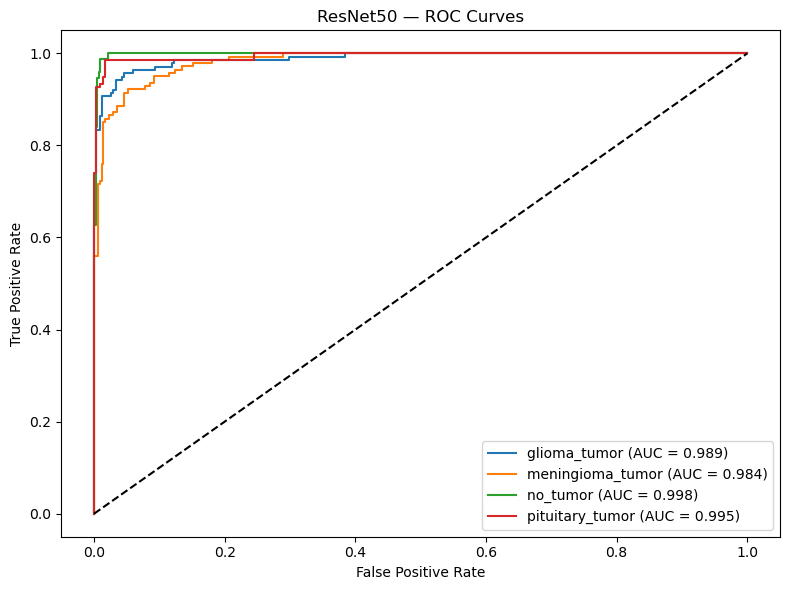

Weighted ROC-AUC: 0.9906


In [11]:
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    auc = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ResNet50 — ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/home/sagemaker-user/NeuroVision/resnet50_roc_curves.png', dpi=150)
plt.show()

overall_auc = roc_auc_score(all_labels_bin, all_probs, average='weighted')
print(f"Weighted ROC-AUC: {overall_auc:.4f}")